# 3. Реализация стека и очереди

### 3.1 Стек

In [74]:
# методы pop, push, peek
class Stack():
    def __init__(self):
        self.items = []
    
    def pop(self):
        if len(self.items) != 0:
            return self.items.pop()
        raise IndexError("Стек пуст")
    
    def push(self, item):
        self.items.append(item)
    
    def peek(self):
        if len(self.items) != 0:
            return self.items[-1]
        raise IndexError("Стек пуст")
    


In [75]:
cl = Stack()

cl.push(10)
cl.push(20)
print(cl.items)
cl.pop()
print(cl.items)

[10, 20]
[10]


### 3.2 Очередь

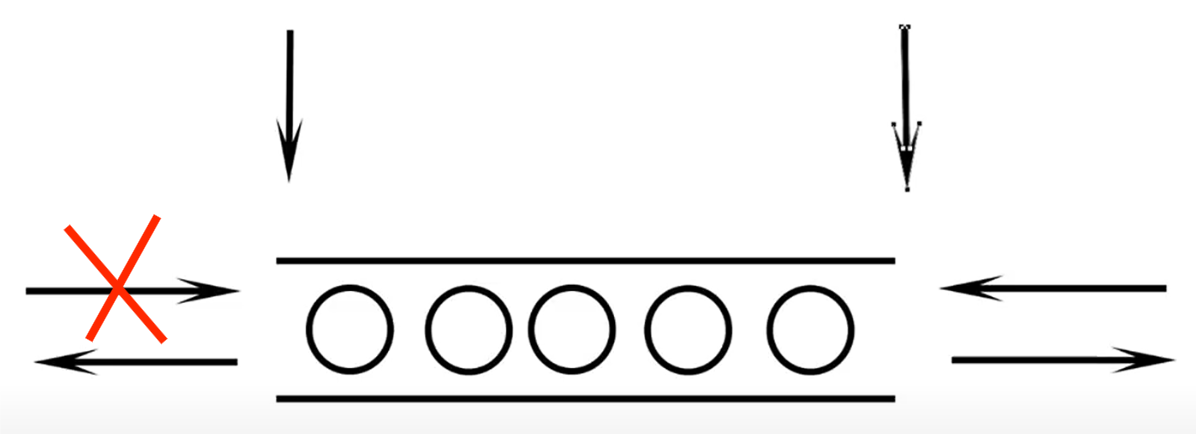

In [76]:
#enqueue, dequeue, peek
class Queue():

    def __init__(self):
        self.items = []
    
    def enqueue(self, item):
        self.items.append(item)
    
    def dequeue(self):
        if len(self.items) != 0:
            return self.items.pop(0)
        raise IndexError("Очередь пуста")
    
    def peek(self):
        if len(self.items) != 0:
            return self.items[0]
        raise IndexError("Очередь пуста")
     


# Задание
## 1. Изучить классы с реализацией стека и очереди
## 2. Написать собственные классы:
### 2.1 Класс для реализации кольцевой очереди
### 2.2 Класс для реализации очереди с приоритетом
### 2.3 Проверка корректности скобочной последовательности
Создайте класс **BrakeStack**, который: <br> Принимает строку, состоящую из скобок, например "()(((()[[[[[]]{}{{)))". <br> Проверяет правильность строки по признаку открытия и закрытия скобок.

In [77]:
class Oqueue: # вроде кольцо
    def __init__(self):
        self.item = []
    def push(self, item):
        self.item.append(item)
    def pop(self):
        if self.item != 0:
            self.item.append(self.peek())
            self.item.pop(0)
            return self.item
        else: print(f'It is EMPTY!')
    def peek(self):
        if self.item != 0: 
            return self.item[0]


In [78]:
c1 = Oqueue()
for i in range(10):
    c1.push(i)
print(c1.item)

for i in range(5):
    c1.pop()
print(c1.item)

c1.peek()

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[5, 6, 7, 8, 9, 0, 1, 2, 3, 4]


5

In [79]:
#Класс приорететов
#casta = ['high', 'avrg', 'low']
class PriorQueue:
    def __init__(self):
        self.item = []
    def push(self, item, casta):
            if item!=None and casta!=None: 
                self.item.append((item,casta))
            else: print(f'Wrong!')
            
    def dequeue(self,target):
        if self.item != 0:
            self.item = [(item, casta) for (item, casta) in self.item if casta != target]
            return self.item
        else: print(f'It is EMPTY!')
    def peek(self):
        if self.item != 0: 
            return self.item[0]

In [80]:
import random
c2 = PriorQueue()

c2.push(10,1)
for i in range(10):
    c2.push(i,random.randint(1,10)) 

print(c2.item)

c2.dequeue(1)
print(c2.item)

[(10, 1), (0, 5), (1, 4), (2, 6), (3, 5), (4, 6), (5, 2), (6, 10), (7, 9), (8, 4), (9, 2)]
[(0, 5), (1, 4), (2, 6), (3, 5), (4, 6), (5, 2), (6, 10), (7, 9), (8, 4), (9, 2)]


In [81]:
class BrakeStack:
    def __init__(self,stack):
        self.stack = stack
        self.item = []
        self.brake = {')':'(', ']':'[', '}':'{'}
            
    def check(self): #Если не важно как стоят скобки, то есть такое )))(((, такое тоже закрывается
        a,b,c,d,e,f = 0,0,0,0,0,0
        dict = {'(':a,')':b,'[':c,']':d,'{':e,'}':f}
        for i in range(len(self.stack)):
            if self.stack[i]=='(':
                a = a+1
                dict = {'(':a,')':b,'[':c,']':d,'{':e,'}':f}
            elif self.stack[i]==')':
                b = b+1
                dict = {'(':a,')':b,'[':c,']':d,'{':e,'}':f}
            elif self.stack[i]=='[':
                c = c+1
                dict = {'(':a,')':b,'[':c,']':d,'{':e,'}':f}
            elif self.stack[i]==']':
                d = d+1
                dict = {'(':a,')':b,'[':c,']':d,'{':e,'}':f}
            elif self.stack[i]=='{':
                e = e+1
                dict = {'(':a,')':b,'[':c,']':d,'{':e,'}':f}
            elif self.stack[i]=='}':
                f = f+1
                dict = {'(':a,')':b,'[':c,']':d,'{':e,'}':f}
        print(dict)
        if dict['('] == dict[')'] and dict['[']==dict[']'] and dict['{']==dict['}']:
            print(f'good')
        else: print(f'not good')

    def check_queue(self): # С учетом положения 
        for arg in self.stack:
            if arg in '([{':
                self.item.append(arg)
            elif arg in '}])':
                if self.item == []:
                    print(f'not good')
                    break
                if self.item[0]!=self.brake[arg]:
                    print(f'not good')
                    break

                self.item.pop()

In [82]:
stack = "()(((()[[[[[]]{}{{)))"
a1 = BrakeStack(stack)
a1.check()
a1.check_queue()

{'(': 5, ')': 5, '[': 5, ']': 2, '{': 3, '}': 1}
not good
not good
